In [1]:
import os
path = '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government'
models = os.listdir(path)
print(models)

['UKESM1-0-LL', 'MPI-ESM1-2-HR', 'NorESM2-MM', 'ACCESS-ESM1-5', 'EC-Earth3-Veg']


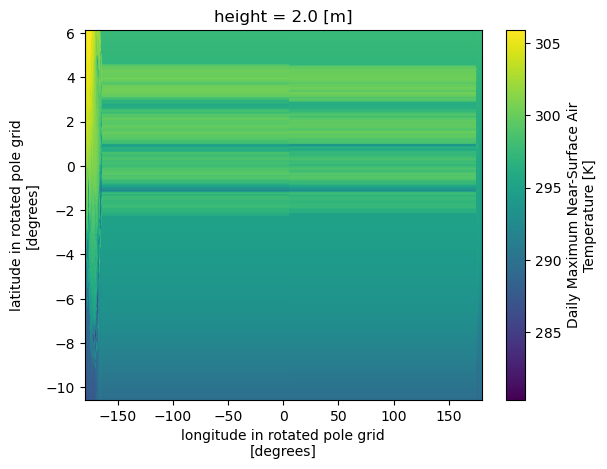

In [3]:
import xarray as xr
import os

narclim_path = '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ACCESS-ESM1-5/historical/r6i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day/tasmax/latest/'
file = os.path.join(narclim_path, 'tasmax_NARCliM2-0-SEAus-04_ACCESS-ESM1-5_historical_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R3_v1-r1_day_19800101-19801231.nc')
ds = xr.open_dataset(file)
ds.tasmax.mean(dim='time').plot()

Found 10 pr files
Selected file: /scratch/w97/mg5624/NARCLIM_regrid/ssp126/tasmax/UKESM1-0-LL/NARCliM2-0-WRF412R5/r1i1p1f2/ssp126_UKESM1-0-LL_NARCliM2-0-WRF412R5_r1i1p1f2_tasmax.nc
<xarray.Dataset> Size: 18GB
Dimensions:  (time: 30960, lat: 412, lon: 350)
Coordinates:
  * time     (time) object 248kB 2015-01-01 12:00:00 ... 2100-12-30 12:00:00
  * lat      (lat) float64 3kB -39.98 -39.94 -39.9 ... -24.1 -24.06 -24.02
  * lon      (lon) float64 3kB 140.0 140.1 140.1 140.1 ... 153.9 153.9 154.0
    height   float64 8B ...
    crs      int64 8B ...
Data variables:
    tasmax   (time, lat, lon) float32 18GB ...
Variable: tasmax
Random timestep: 24965


/scratch/w97/mg5624/tmp/ipykernel_1906297/2916092252.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntime = ds.dims.get("time", None)
<frozen _collections_abc>:807: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


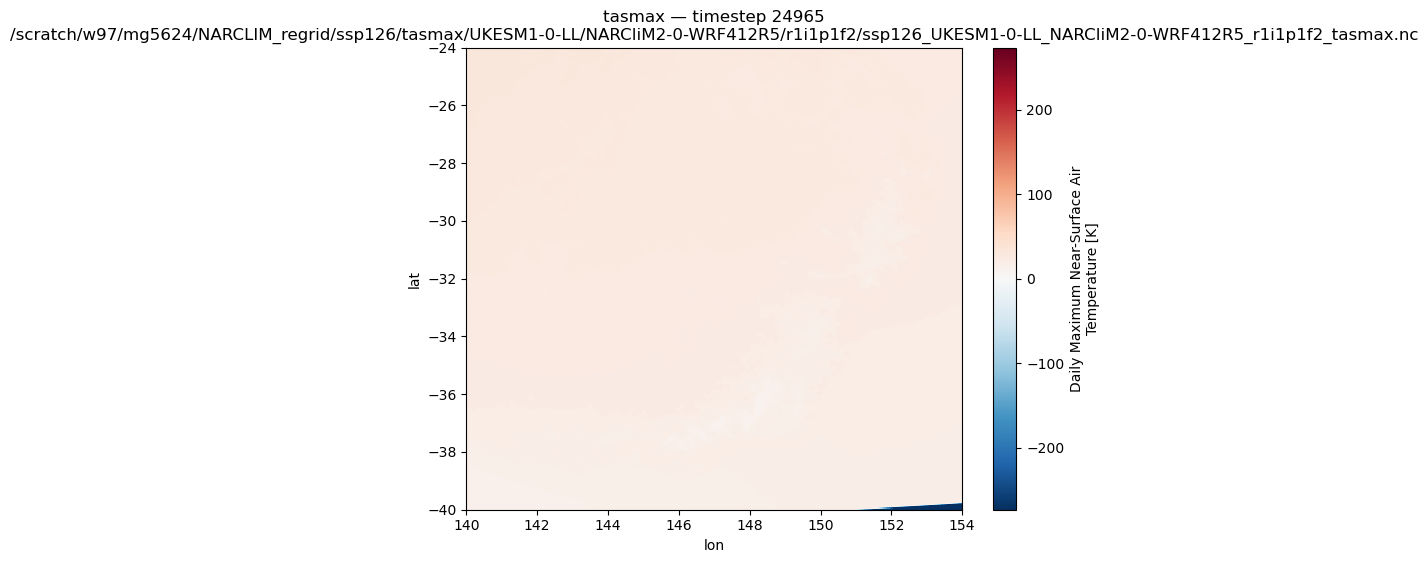

In [2]:
import random
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Root directory
root = Path("/scratch/w97/mg5624/NARCLIM_regrid")

# Find all NetCDF files that have '/pr/' somewhere in their path
files = [f for f in root.rglob("*.nc") if "ssp126/tasmax/" in str(f)]

print(f"Found {len(files)} pr files")

if len(files) == 0:
    raise FileNotFoundError("No pr files found anywhere under the root directory")

# Randomly select one file
selected = random.choice(files)
print("Selected file:", selected)

# Open dataset
ds = xr.open_dataset(selected)
print(ds)

# Pick first data variable
var = list(ds.data_vars)[0]
print("Variable:", var)

# Random timestep
ntime = ds.dims.get("time", None)
if ntime is None:
    raise ValueError("Dataset has no time dimension")

t = np.random.randint(0, ntime)
print("Random timestep:", t)

year = '2040'
da = ds[var].sel(time=year)

# Plot
plt.figure(figsize=(8,6))
da.mean(dim='time').plot()
plt.title(f"{var} — timestep {t}\n{selected}")
plt.show()


In [4]:
ds

<xarray.Dataset> Size: 18GB
Dimensions:  (time: 30960, lat: 412, lon: 350)
Coordinates:
  * time     (time) object 248kB 2015-01-01 12:00:00 ... 2100-12-30 12:00:00
  * lat      (lat) float64 3kB -39.98 -39.94 -39.9 ... -24.1 -24.06 -24.02
  * lon      (lon) float64 3kB 140.0 140.1 140.1 140.1 ... 153.9 153.9 154.0
    height   float64 8B ...
    crs      int64 8B ...
Data variables:
    tasmax   (time, lat, lon) float32 18GB ...

In [ ]:
import xarray as xr
vars = [
    'tasmax',
    'tasmin',
    'pr',
    'mrsos',
]



path = '/scratch/w97/mg5624/NARCLIM_regrid/historical/pr/ACCESS-ESM1-5/NARCliM2-0-WRF412R3/r6i1p1f1/'
file = 'historical_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_r6i1p1f1_pr.nc'
ds = xr.open_dataset(path + file)
ds

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-26.04/share/proj failed


<xarray.Dataset> Size: 16GB
Dimensions:  (time: 23376, lat: 444, lon: 388)
Coordinates:
  * time     (time) datetime64[ns] 187kB 1951-01-01T12:00:00 ... 2014-12-31T1...
  * lat      (lat) float64 4kB -39.98 -39.95 -39.91 ... -24.09 -24.05 -24.02
  * lon      (lon) float64 3kB 140.0 140.1 140.1 140.1 ... 153.9 153.9 154.0
    crs      int64 8B ...
Data variables:
    pr       (time, lat, lon) float32 16GB ...

In [4]:
ds.pr.isel(time=slice(None, 10000)).mean(dim=['lat', 'lon']).plot()

: 

In [11]:
import xarray as xr
model = 'ACCESS-ESM1-5'
scenario = 'historical'
path = f'/scratch/w97/mg5624/NARCLIM_regrid/{scenario}/pr/{model}/NARCliM2-0-WRF412R3/r6i1p1f1/'
file = f'{scenario}_{model}_NARCliM2-0-WRF412R3_r6i1p1f1_pr.nc'
ds = xr.open_dataset(path + file)
leap_year = ds.sel(time=slice('2023-02-01', '2023-03-01'))
leap_year.time


<xarray.DataArray 'time' (time: 0)> Size: 0B
array([], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 0B 
    crs      int64 8B ...
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds

In [12]:
import numpy as np
baseline_data = ds.pr

years = np.unique(baseline_data["time.year"].values)

# Identify non-leap years (those missing Feb 29)
non_leap_years = [
    y for y in years
    if (2, 29) not in set(zip(
        baseline_data.sel(time=str(y))["time.month"].values,
        baseline_data.sel(time=str(y))["time.day"].values
    ))
]
feb28 = baseline_data.sel(
    time=(
        (baseline_data["time.month"] == 2)
        & (baseline_data["time.day"] == 28)
        & baseline_data["time.year"].isin(non_leap_years)
    )
)

# Create synthetic Feb 29 by shifting Feb 28 by +1 day
feb28_coords = feb28["time"] + np.timedelta64(1, "D")
print(feb28_coords)
feb28 = feb28.assign_coords(time=("time", feb28_coords))

<xarray.DataArray 'time' (time: 48)> Size: 384B
array(['1951-03-01T12:00:00.000000000', '1953-03-01T12:00:00.000000000',
       '1954-03-01T12:00:00.000000000', '1955-03-01T12:00:00.000000000',
       '1957-03-01T12:00:00.000000000', '1958-03-01T12:00:00.000000000',
       '1959-03-01T12:00:00.000000000', '1961-03-01T12:00:00.000000000',
       '1962-03-01T12:00:00.000000000', '1963-03-01T12:00:00.000000000',
       '1965-03-01T12:00:00.000000000', '1966-03-01T12:00:00.000000000',
       '1967-03-01T12:00:00.000000000', '1969-03-01T12:00:00.000000000',
       '1970-03-01T12:00:00.000000000', '1971-03-01T12:00:00.000000000',
       '1973-03-01T12:00:00.000000000', '1974-03-01T12:00:00.000000000',
       '1975-03-01T12:00:00.000000000', '1977-03-01T12:00:00.000000000',
       '1978-03-01T12:00:00.000000000', '1979-03-01T12:00:00.000000000',
       '1981-03-01T12:00:00.000000000', '1982-03-01T12:00:00.000000000',
       '1983-03-01T12:00:00.000000000', '1985-03-01T12:00:00.000000000',
   

TypeError: Variable 'time': Using a DataArray object to construct a variable is ambiguous, please extract the data using the .data property.

<xarray.DataArray 'time' (time: 29)> Size: 232B
array([cftime.DatetimeNoLeap(2004, 2, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 3, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 4, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 5, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 6, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 7, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 8, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 9, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 10, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 11, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 12, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 13, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 14, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 15, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 17, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 18, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 19, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 20, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 21, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 22, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 23, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 24, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 25, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 26, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 27, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 28, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 3, 1, 12, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 232B 2004-02-01 12:00:00 ... 2004-03-01 12:00:00
    crs      int64 8B ...
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds

In [1]:
import xarray as xr
test = xr.open_dataset('/g/data/w97/mg5624/ABS_project/extremes/daily/gdd_1950-2021_1.nc')
test

<xarray.Dataset> Size: 31GB
Dimensions:              (time: 26298, lat: 691, lon: 426)
Coordinates:
  * time                 (time) datetime64[ns] 210kB 1950-01-01T09:00:00 ... ...
  * lat                  (lat) float32 3kB -44.5 -44.45 -44.4 ... -10.05 -10.0
  * lon                  (lon) float32 2kB 135.0 135.1 135.1 ... 156.2 156.2
Data variables:
    growing_degree_days  (time, lat, lon) float32 31GB ...
Attributes:
    units:                      degrees_Celsius
    analysis_version_number:    3.51
    standard_name:              air_temperature
    frequency:                  daily
    length_scale_for_analysis:  250.0
    grid_mapping:               crs
    coverage_content_type:      physicalMeasurement
    valid_range:                [-100.  100.]